In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

In [2]:
df = pd.read_csv(r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\hourly_device_energy.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
df.head()

,Appliance Type,Energy Consumption (kWh)
timestamp,,
2023-01-01 00:00:00,Air Conditioning,4.42
2023-01-01 01:00:00,Air Conditioning,7.61
2023-01-01 02:00:00,Air Conditioning,14.80
2023-01-01 03:00:00,Air Conditioning,4.19
2023-01-01 04:00:00,Air Conditioning,10.68


In [4]:
hourly = df.resample('h').sum()
daily = df.resample('D').sum()
weekly = df.resample('W').sum()
monthly = df.resample('ME').sum()

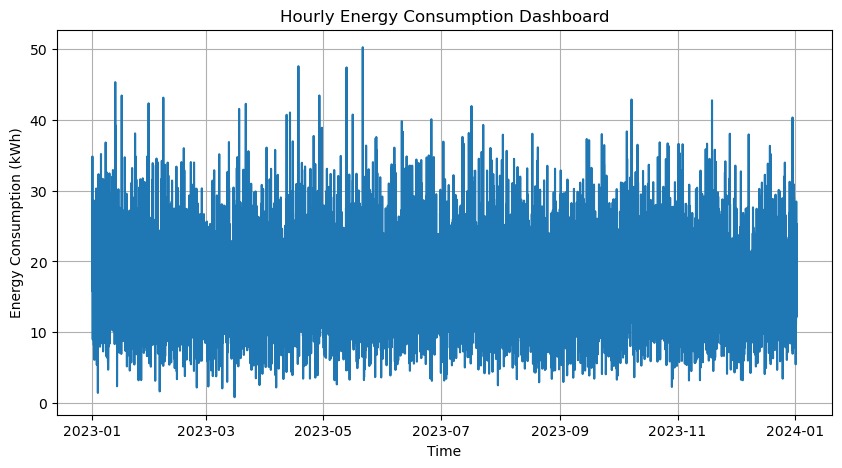

In [16]:
plt.figure(figsize=(10,5))
plt.plot(hourly['Energy Consumption (kWh)'])
plt.title("Hourly Energy Consumption Dashboard")
plt.xlabel("Time")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)
plt.show()

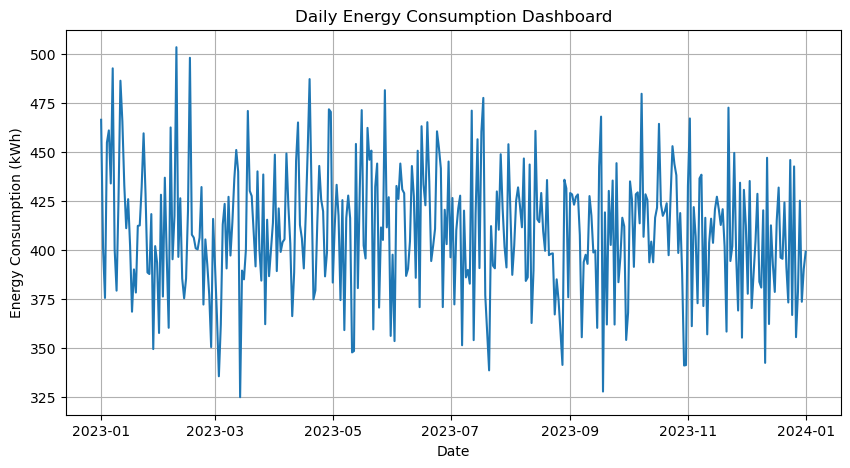

In [19]:
plt.figure(figsize=(10,5))
plt.plot(daily['Energy Consumption (kWh)'])
plt.title("Daily Energy Consumption Dashboard")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)
plt.show()

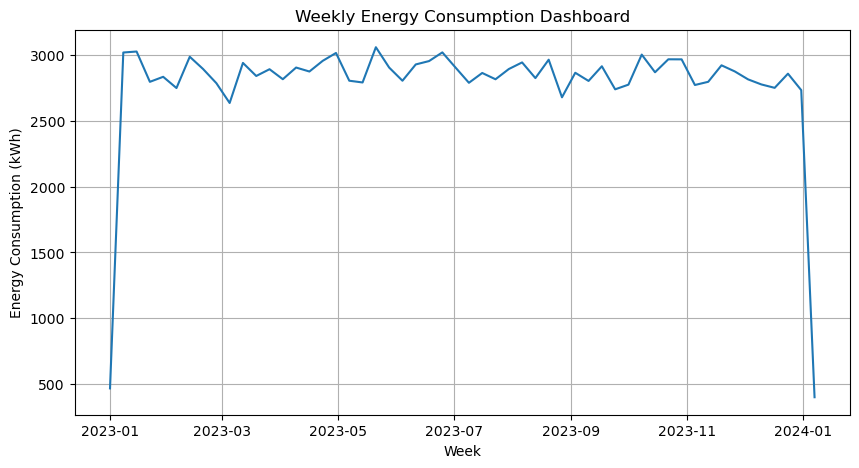

In [20]:
plt.figure(figsize=(10,5))
plt.plot(weekly['Energy Consumption (kWh)'])
plt.title("Weekly Energy Consumption Dashboard")
plt.xlabel("Week")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)
plt.show()

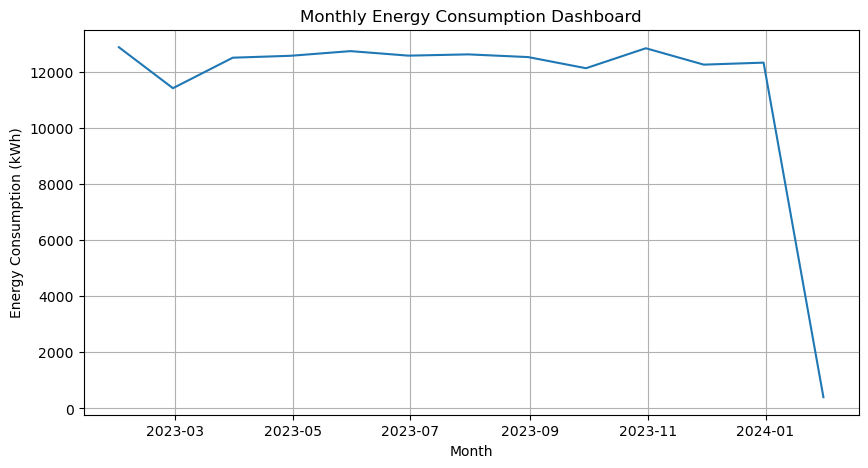

In [21]:
plt.figure(figsize=(10,5))
plt.plot(monthly['Energy Consumption (kWh)'])
plt.title("Monthly Energy Consumption Dashboard")
plt.xlabel("Month")
plt.ylabel("Energy Consumption (kWh)")
plt.grid(True)
plt.show()

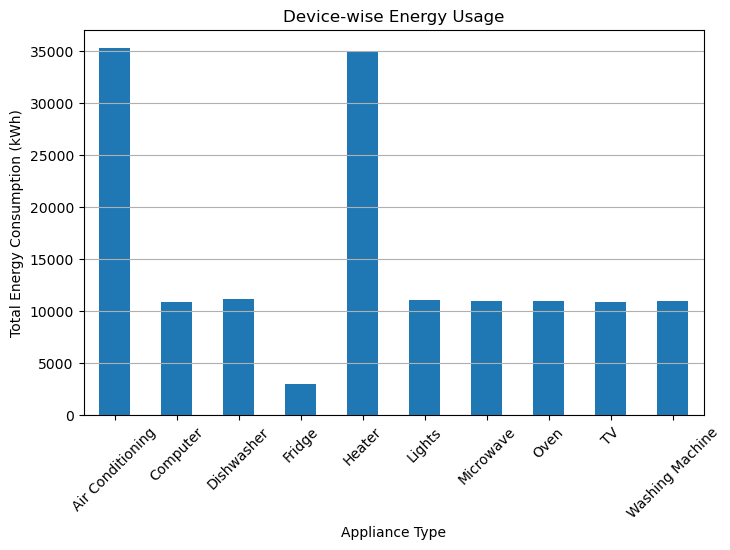

In [18]:
#Display device-wise usage charts using matplotlib. 
df_device = pd.read_csv(
    r"C:\Users\mucha\OneDrive\Desktop\Infosys internship\Processed\device_level.csv"
)
df_device.columns = df_device.columns.str.strip()

def plot_device_usage():
    device_usage = df_device.groupby('Appliance Type')['Energy Consumption (kWh)'].sum()
    plt.figure(figsize=(8,5))
    device_usage.plot(kind='bar')
    plt.title("Device-wise Energy Usage")
    plt.xlabel("Appliance Type")
    plt.ylabel("Total Energy Consumption (kWh)")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()

plot_device_usage()

In [15]:
def generate_smart_suggestions(df):
    suggestions = []
    
    print("\nSMART ENERGY SAVING SUGGESTIONS:\n")
    
    # Overall statistics
    avg = df['Energy Consumption (kWh)'].mean()
    peak = df['Energy Consumption (kWh)'].max()

    # 1️⃣ Peak usage detection
    if peak > avg * 1.5:
        suggestions.append("⚠ High peak energy usage detected. Avoid running heavy appliances simultaneously.")

    # 2️⃣ Device-level total usage
    device_usage = df.groupby('Appliance Type')['Energy Consumption (kWh)'].sum()
    
    # Find highest energy consuming device
    highest_device = device_usage.idxmax()
    highest_value = device_usage.max()
    
    # Add warning for highest device
    suggestions.append(
        f"💡 {highest_device} consumes the most energy ({highest_value:.2f} kWh). Consider reducing its usage during peak hours."
    )

    # 3️⃣ Suggestions for each device
    for device, usage in device_usage.items():
        if usage > device_usage.mean():
            
            if "Air" in device or "AC" in device:
                suggestions.append(f"- 🌡 Reduce temperature settings or usage duration of {device}.")
                
            elif "Heater" in device:
                suggestions.append(f"- 🔥 Use {device} efficiently and avoid continuous operation.")
                
            elif "Refrigerator" in device:
                suggestions.append(f"- ❄ Ensure proper door sealing and avoid frequent opening of {device}.")
                
            else:
                suggestions.append(f"- ⚡ Monitor and optimize usage of {device}.")
    for s in suggestions:
        print("-", s)
generate_smart_suggestions(df)


SMART ENERGY SAVING SUGGESTIONS:

- ⚠ High peak energy usage detected. Avoid running heavy appliances simultaneously.
- 💡 Air Conditioning consumes the most energy (35233.06 kWh). Consider reducing its usage during peak hours.
- - 🌡 Reduce temperature settings or usage duration of Air Conditioning.
- - 🔥 Use Heater efficiently and avoid continuous operation.
